In [6]:
import pandas as pd

# Load the dataset
df = pd.read_csv("data/housing.csv")

# Display first 5 rows
print(df.head())

   area_sqft  bedrooms  bathrooms  house_age_years  parking_spaces  price_usd
0       1200         2          2                5               1     250000
1       1500         3          2                8               1     320000
2       1800         3          3                2               2     410000
3       2200         4          3               10               2     520000
4        950         2          1               15               0     180000


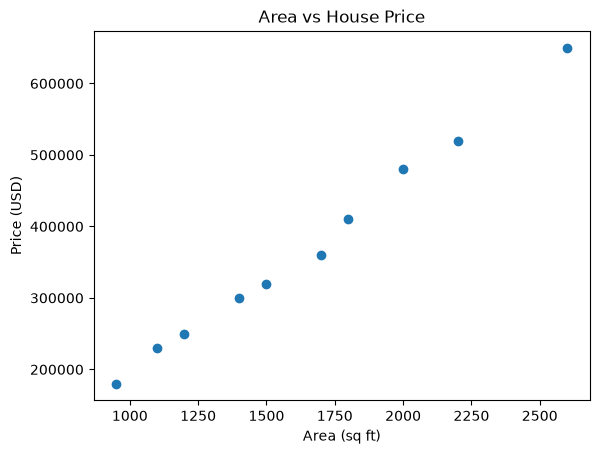

In [8]:
import matplotlib.pyplot as plt

plt.scatter(df["area_sqft"], df["price_usd"])
plt.xlabel("Area (sq ft)")
plt.ylabel("Price (USD)")
plt.title("Area vs House Price")
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

# Features (input variables)
X = df.drop("price_usd", axis=1)

# Target (output variable)
y = df["price_usd"]

# Split the data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Check the sizes
print("Training features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training labels shape:", y_train.shape)
print("Testing labels shape:", y_test.shape)

Training features shape: (8, 5)
Testing features shape: (2, 5)
Training labels shape: (8,)
Testing labels shape: (2,)


In [10]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

print("✅ Linear Regression model trained successfully!")

✅ Linear Regression model trained successfully!


In [11]:
# Predict prices for the test set
y_pred = model.predict(X_test)

# Display actual vs predicted prices
results = X_test.copy()
results["Actual Price"] = y_test.values
results["Predicted Price"] = y_pred

print(results)

   area_sqft  bedrooms  bathrooms  house_age_years  parking_spaces  \
8       2600         5          4                3               2   
1       1500         3          2                8               1   

   Actual Price  Predicted Price  
8        650000    626580.158527  
1        320000    327611.498703  


In [12]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("----------------")
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("R² Score:", r2)

Model Evaluation
----------------
Mean Absolute Error (MAE): 15515.670088030165
Mean Squared Error (MSE): 303211943.5599225
R² Score: 0.9888627385285611


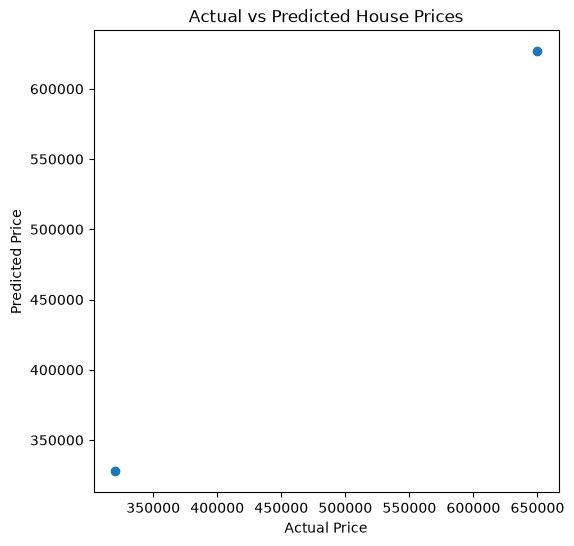

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()


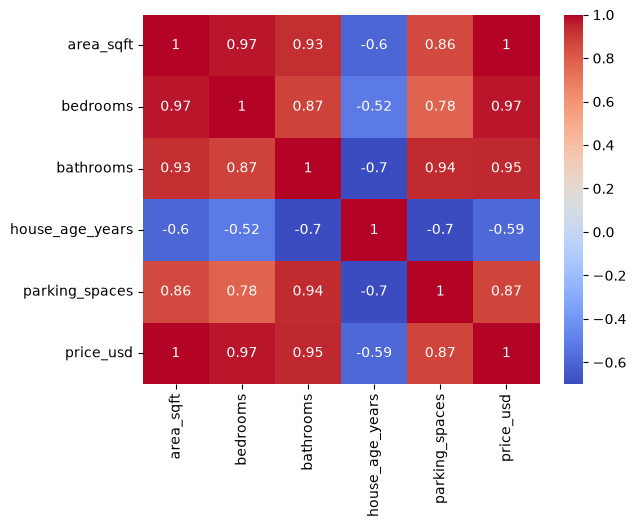

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [17]:
import joblib

joblib.dump(model, "house_price_model.pkl")

['house_price_model.pkl']